In [ ]:
import pandas as pd

# Substitua o caminho pelo seu arquivo
df = pd.read_csv('df_final.csv')

In [ ]:
df.head()

,Unnamed: 0,Ano,CNAE2,informal,CLT,Contrato_Temp,informal_pct,CLT_pct,Contrato_Temp_pct,q_it_raw,q_it
0,0,2012,10,0.217365,0.868198,0.114841,21.736472,86.819788,11.484099,1858580.23,18.585802
1,1,2012,11,0.094077,0.927007,0.029197,9.407666,92.700730,2.919708,3433776.36,34.337764
2,2,2012,12,0.079365,0.901639,0.262295,7.936508,90.163934,26.229508,1268764.42,12.687644
3,3,2012,13,0.513224,0.825230,0.085414,51.322373,82.522996,8.541393,1175709.32,11.757093
4,4,2012,14,0.562912,0.749351,0.060716,56.291216,74.935132,6.071614,970663.42,9.706634


In [ ]:
df.columns

Index(['Unnamed: 0', 'Ano', 'CNAE2', 'informal', 'CLT', 'Contrato_Temp',
       'informal_pct', 'CLT_pct', 'Contrato_Temp_pct', 'q_it_raw', 'q_it'],
      dtype='object')

In [ ]:
import pandas as pd

# Agrupa por Ano e CNAE e calcula a média
df_pct_2 = df.groupby(['Ano', 'CNAE2']).agg({
    'informal': 'mean',
    'CLT': 'mean',
    'Contrato_Temp': 'mean',
}).reset_index()

# Converte para porcentagem
df_pct_2['informal_pct'] = df_pct_2['informal'] * 100
df_pct_2['CLT_pct'] = df_pct_2['CLT'] * 100
df_pct_2['Contrato_Temp_pct'] = df_pct_2['Contrato_Temp'] * 100

# Agora, df_pct tem as colunas Ano e CNAE
print(df_pct_2.head())

    Ano  CNAE2  informal       CLT  Contrato_Temp  informal_pct    CLT_pct  \
0  2012     10  0.217365  0.868198       0.114841     21.736472  86.819788   
1  2012     11  0.094077  0.927007       0.029197      9.407666  92.700730   
2  2012     12  0.079365  0.901639       0.262295      7.936508  90.163934   
3  2012     13  0.513224  0.825230       0.085414     51.322373  82.522996   
4  2012     14  0.562912  0.749351       0.060716     56.291216  74.935132   

   Contrato_Temp_pct  
0          11.484099  
1           2.919708  
2          26.229508  
3           8.541393  
4           6.071614  


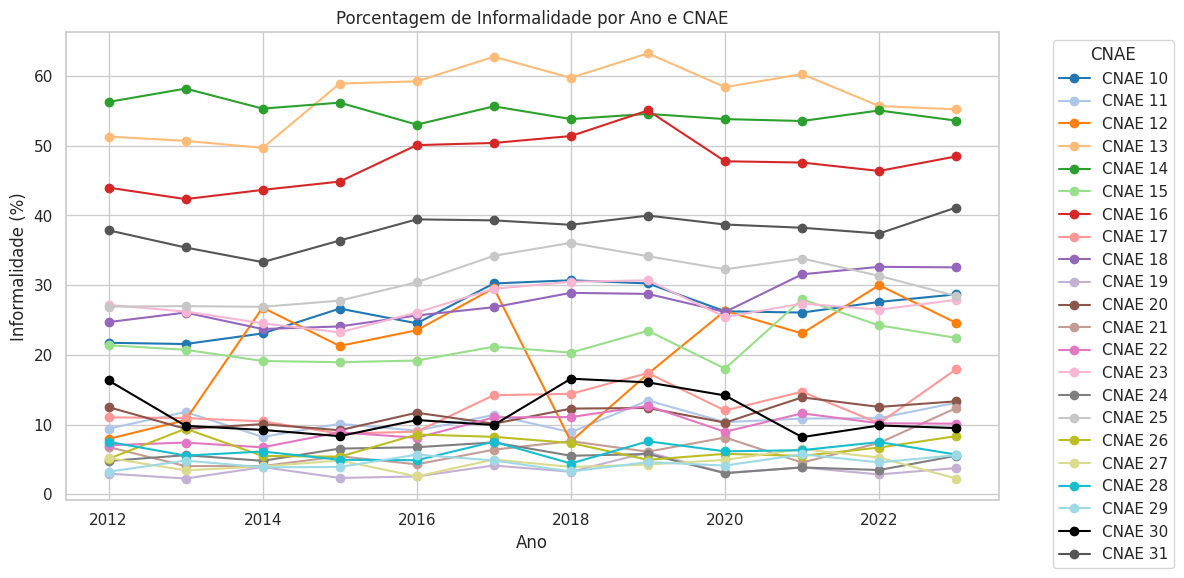

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de CNAEs únicos
cnaes = df_pct_2['CNAE2'].unique()

# Criar um dicionário para cores, colocando CNAE 30 e 31 manualmente
palette_dict = {}

# Definir cores específicas para CNAE 30 e 31
palette_dict[30] = '#000000'      # Preto
palette_dict[31] = '#555555'      # Cinza escuro

# Para os demais CNAEs, usar uma paleta padrão
cores = sns.color_palette("tab20", len(cnaes))
conta = 0
for cnae in cnaes:
    # Se não for CNAE 30 ou 31, atribuir cores da paleta
    if cnae not in [30, 31]:
        # Evitar sobrescrever as cores previamente atribuídas
        palette_dict[cnae] = cores[conta]
        conta += 1

plt.figure(figsize=(12,6))

# Plotando cada CNAE com sua cor definida
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    plt.plot(
        data_cnae['Ano'],
        data_cnae['informal_pct'],
        label=f'CNAE {cnae}',
        color=palette_dict[cnae],
        marker='o'
    )

plt.title('Porcentagem de Informalidade por Ano e CNAE')
plt.xlabel('Ano')
plt.ylabel('Informalidade (%)')
plt.legend(title='CNAE', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

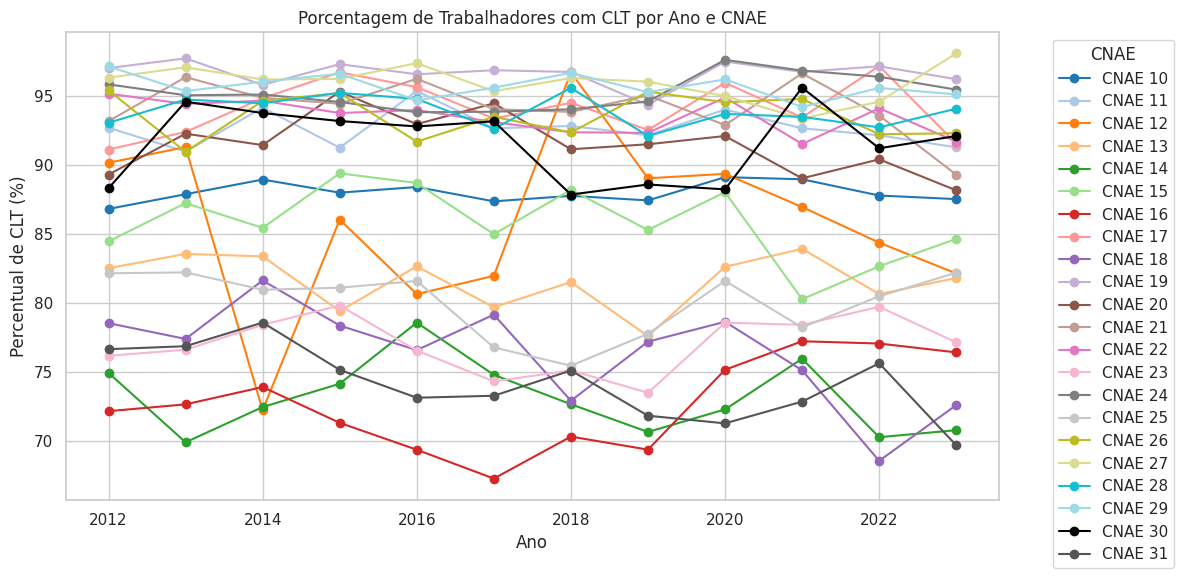

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de CNAEs únicos
cnaes = df_pct_2['CNAE2'].unique()

# Criar um dicionário para cores, colocando CNAE 30 e 31 manualmente
palette_dict = {}

# Definir cores específicas para CNAE 30 e 31
palette_dict[30] = '#000000'      # Preto
palette_dict[31] = '#555555'      # Cinza escuro

# Para os demais CNAEs, usar uma paleta padrão
cores = sns.color_palette("tab20", len(cnaes))
conta = 0
for cnae in cnaes:
    # Se não for CNAE 30 ou 31, atribuir cores da paleta
    if cnae not in [30, 31]:
        # Evitar sobrescrever as cores previamente atribuídas
        palette_dict[cnae] = cores[conta]
        conta += 1

plt.figure(figsize=(12,6))

# Plotando cada CNAE com sua cor definida
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    plt.plot(
        data_cnae['Ano'],
        data_cnae['CLT_pct'],
        label=f'CNAE {cnae}',
        color=palette_dict[cnae],
        marker='o'
    )

plt.title('Porcentagem de Trabalhadores com CLT por Ano e CNAE')
plt.xlabel('Ano')
plt.ylabel('Percentual de CLT (%)')
plt.legend(title='CNAE', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

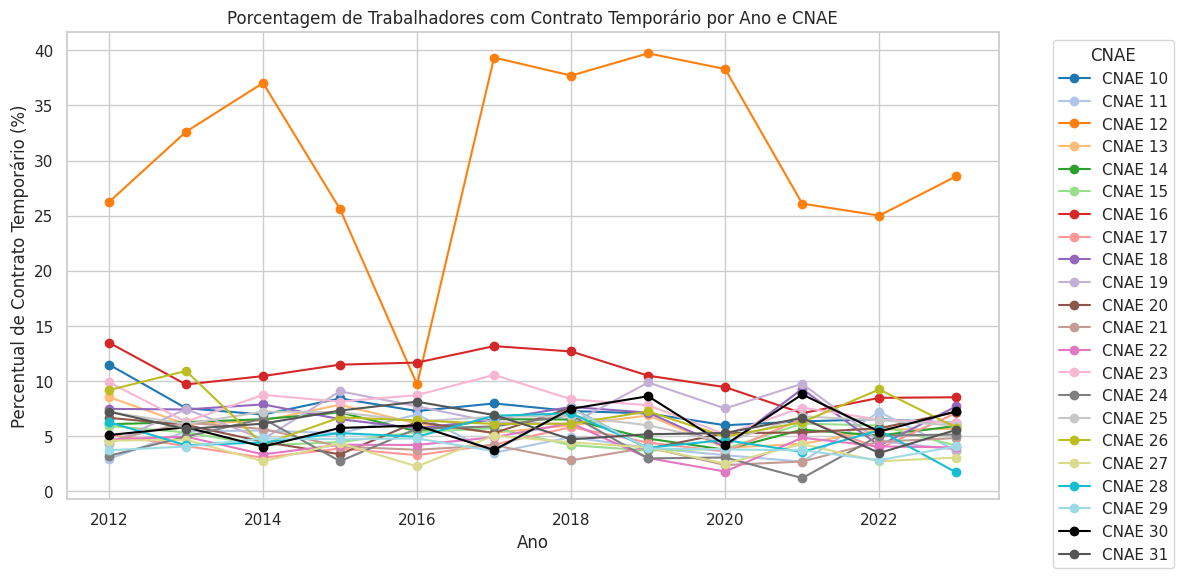

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de CNAEs únicos
cnaes = df_pct_2['CNAE2'].unique()

# Criar um dicionário para cores, colocando CNAE 30 e 31 manualmente
palette_dict = {}

# Definir cores específicas para CNAE 30 e 31
palette_dict[30] = '#000000'      # Preto
palette_dict[31] = '#555555'      # Cinza escuro

# Para os demais CNAEs, usar uma paleta padrão
cores = sns.color_palette("tab20", len(cnaes))
conta = 0
for cnae in cnaes:
    # Se não for CNAE 30 ou 31, atribuir cores da paleta
    if cnae not in [30, 31]:
        # Evitar sobrescrever as cores previamente atribuídas
        palette_dict[cnae] = cores[conta]
        conta += 1

plt.figure(figsize=(12,6))

# Plotando cada CNAE com sua cor definida
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    plt.plot(
        data_cnae['Ano'],
        data_cnae['Contrato_Temp_pct'],
        label=f'CNAE {cnae}',
        color=palette_dict[cnae],
        marker='o'
    )

plt.title('Porcentagem de Trabalhadores com Contrato Temporário por Ano e CNAE')
plt.xlabel('Ano')
plt.ylabel('Percentual de Contrato Temporário (%)')
plt.legend(title='CNAE', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
df_pct_2.to_csv('df_pct_2.csv')

/tmp/ipython-input-1016210888.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().set_visible(False)  # Remover legenda


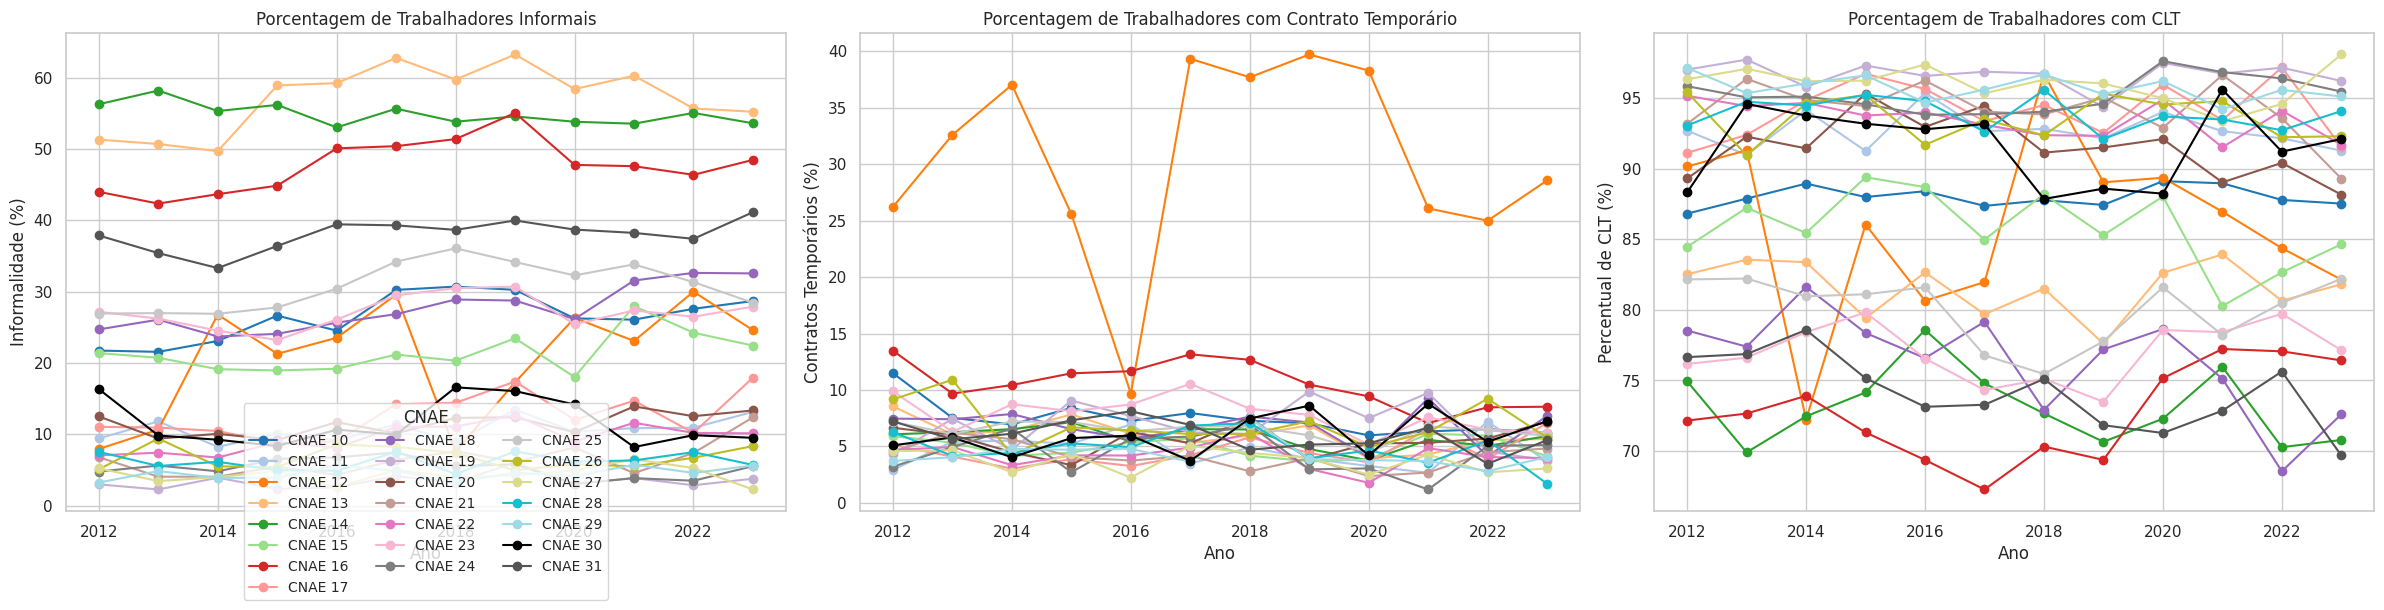

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Lista de CNAEs únicos
cnaes = df_pct_2['CNAE2'].unique()

# Criar dicionários de cores para os gráficos
palette_dict_pct = {}
palette_dict_clt = {}

# Definir cores específicas para CNAE 30 e 31
palette_dict_pct[30] = '#000000'
palette_dict_pct[31] = '#555555'
palette_dict_clt[30] = '#000000'
palette_dict_clt[31] = '#555555'

# Para os demais CNAEs, usar uma paleta padrão
cores = sns.color_palette("tab20", len(cnaes))
conta_pct = 0
conta_clt = 0
for cnae in cnaes:
    if cnae not in [30, 31]:
        palette_dict_pct[cnae] = cores[conta_pct]
        palette_dict_clt[cnae] = cores[conta_clt]
        conta_pct += 1
        conta_clt += 1

# Criar a figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=False)

# --- Gráfico 1: Informalidade ---
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    axes[0].plot(
        data_cnae['Ano'],
        data_cnae['informal_pct'],
        label=f'CNAE {cnae}',
        color=palette_dict_pct[cnae],
        marker='o'
    )
axes[0].set_title('Porcentagem de Trabalhadores Informais')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Informalidade (%)')
# Legenda na parte inferior
#axes[0].legend(title='CNAE', loc='lower center', bbox_to_anchor=(0.6, -0.1), ncol=3, fontsize='small')



# --- Gráfico 2: Contrato Temporário ---
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    axes[1].plot(
        data_cnae['Ano'],
        data_cnae['Contrato_Temp_pct'],
        color=palette_dict_pct[cnae],
        marker='o'
    )
axes[1].set_title('Porcentagem de Trabalhadores com Contrato Temporário')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Contratos Temporários (%)')
axes[1].legend().set_visible(False)  # Remover legenda

# --- Gráfico 3: CLT ---
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    axes[2].plot(
        data_cnae['Ano'],
        data_cnae['CLT_pct'],
        color=palette_dict_clt[cnae],
        marker='o'
    )
axes[2].set_title('Porcentagem de Trabalhadores com CLT')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Percentual de CLT (%)')
#axes[2].legend().set_visible(False)  # Remover legenda

# --- Legenda vertical de CNAEs à direita ---
#handles = [Line2D([0], [0], color=palette_dict_pct[cnae], marker='o', linestyle='None') for cnae in cnaes]
# Adiciona uma legenda na última subplot (que fica vazia)


plt.tight_layout()
plt.show()

/tmp/ipython-input-2813773257.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().set_visible(False)
/tmp/ipython-input-2813773257.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend().set_visible(False)


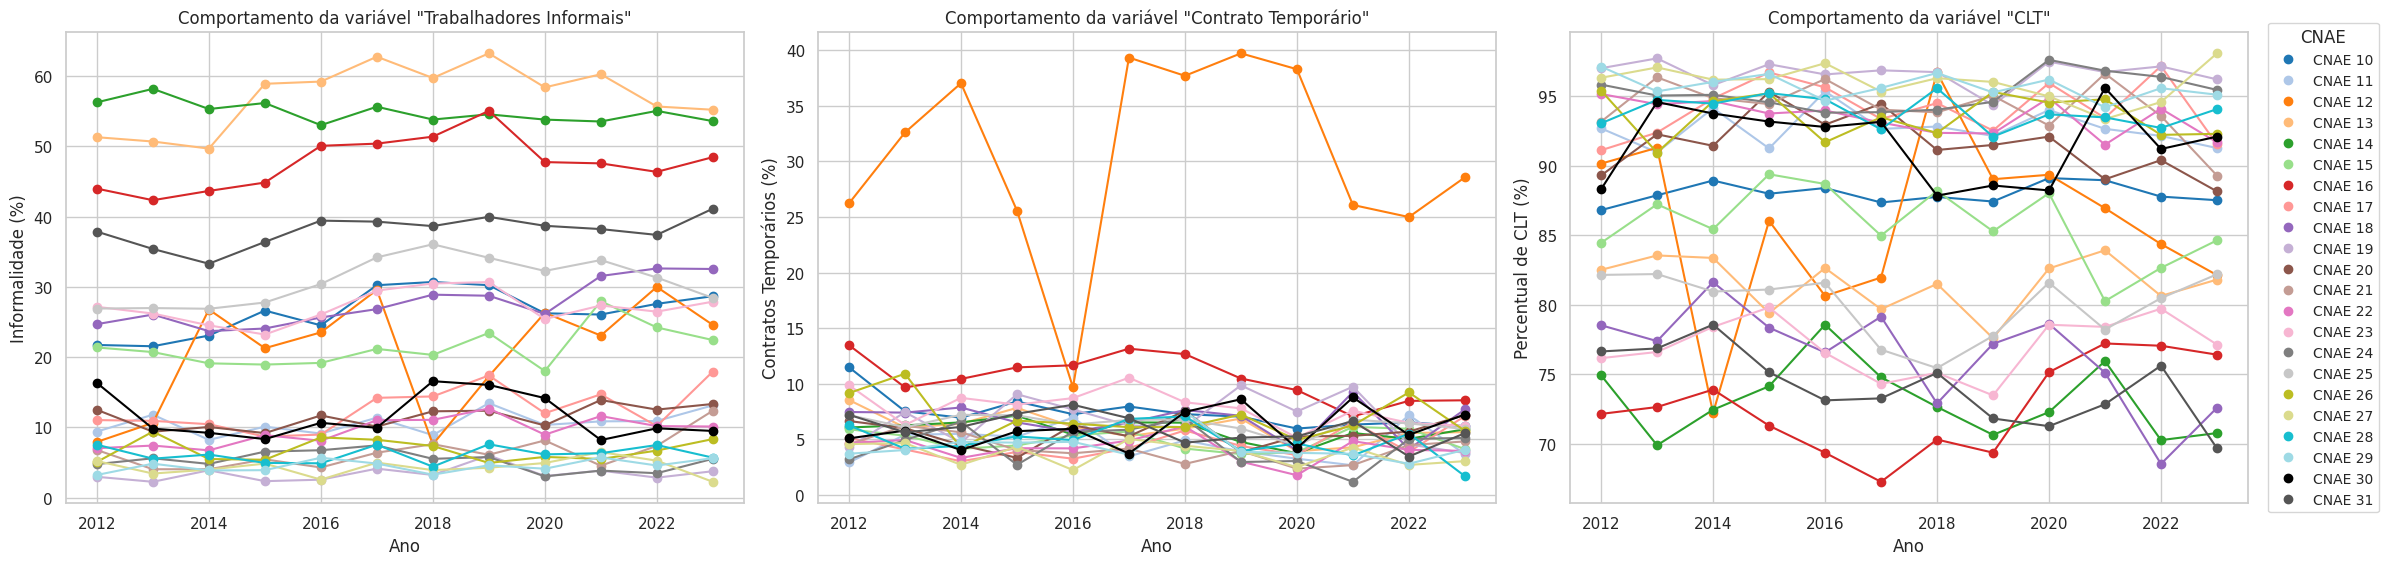

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ... seus dados, cnaes, palettes...

# Criar a figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=False)

# --- Gráfico 1: Informalidade ---
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    axes[0].plot(
        data_cnae['Ano'],
        data_cnae['informal_pct'],
        label=f'CNAE {cnae}',
        color=palette_dict_pct[cnae],
        marker='o'
    )
axes[0].set_title('Comportamento da variável "Trabalhadores Informais"')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Informalidade (%)')

# --- Legenda do primeiro gráfico (opcional) ---
# Opcional: remover, pois iremos colocar só no final
# axes[0].legend().set_visible(False)

# --- Gráfico 2: Contrato Temporário ---
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    axes[1].plot(
        data_cnae['Ano'],
        data_cnae['Contrato_Temp_pct'],
        color=palette_dict_pct[cnae],
        marker='o'
    )
axes[1].set_title('Comportamento da variável "Contrato Temporário"')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Contratos Temporários (%)')
axes[1].legend().set_visible(False)

# --- Gráfico 3: CLT ---
for cnae in cnaes:
    data_cnae = df_pct_2[df_pct_2['CNAE2'] == cnae]
    axes[2].plot(
        data_cnae['Ano'],
        data_cnae['CLT_pct'],
        color=palette_dict_clt[cnae],
        marker='o'
    )
axes[2].set_title('Comportamento da variável "CLT"')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Percentual de CLT (%)')
axes[2].legend().set_visible(False)

# Agora, coloque a legenda grande na lateral direita do gráfico, fora do último gráfico
# Usar `legend()` na figura, com `bbox_to_anchor`
handles, labels = [], []

# Criar handles e labels manualmente para toda a legenda do lado direito
for cnae in cnaes:
    # deve-se reusar as cores já atribuídas
    color = palette_dict_clt[cnae]
    handles.append(Line2D([0], [0], color=color, marker='o', linestyle=''))
    labels.append(f'CNAE {cnae}')

# Adiciona a legenda ao lado direito do último gráfico
axes[2].legend(
    handles=handles,
    labels=labels,
    title='CNAE',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize='small'
)

# Ajustar o layout para espaço extra ao lado direito
plt.subplots_adjust(right=0.75, bottom=0.2)  # aumenta a margem direita
plt.tight_layout()
plt.show()

In [ ]:
df.shape

(264, 9)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Ano', 'CNAE2', 'informal', 'CLT', 'Contrato_Temp',
       'informal_pct', 'CLT_pct', 'Contrato_Temp_pct'],
      dtype='object')

In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Supondo que seu DataFrame seja chamado df
# Certifique-se de que 'Ano' e 'CNAE2' estão como variáveis categóricas
df['Ano'] = df['Ano'].astype('category')
df['CNAE2'] = df['CNAE2'].astype('category')

# Ajuste do modelo com efeitos aleatórios
# Testando a especificação com a função MixedLM
# A variável dependente é 'q_it'
# Variáveis explicativas: 'informal_pct', 'CLT_pct', 'Contrato_Temp_pct'
# Agrupamento por 'CNAE2' (efeitos aleatórios)
import statsmodels.formula.api as smf

model = smf.mixedlm("q_it ~ informal_pct + CLT_pct + Contrato_Temp_pct",
                    df, groups=df["CNAE2"])
result = model.fit()

print(result.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   q_it     
No. Observations:   264       Method:               REML     
No. Groups:         22        Scale:                64.7965  
Min. group size:    12        Log-Likelihood:       -956.3880
Max. group size:    12        Converged:            Yes      
Mean group size:    12.0                                     
-------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025  0.975]
-------------------------------------------------------------
Intercept         69.704   26.352  2.645 0.008 18.056 121.352
informal_pct      -0.582    0.170 -3.432 0.001 -0.914  -0.250
CLT_pct           -0.476    0.268 -1.778 0.075 -1.001   0.049
Contrato_Temp_pct  0.149    0.194  0.767 0.443 -0.232   0.530
Group Var         97.300    4.235                            



In [ ]:
# Supondo que seu DataFrame seja chamado df
# Certifique-se de que 'Ano' e 'CNAE2' estão como variáveis categóricas
df['Ano'] = df['Ano'].astype('category')
df['CNAE2'] = df['CNAE2'].astype('category')

# Ajuste do modelo com efeitos aleatórios
# Testando a especificação com a função MixedLM
# A variável dependente é 'q_it'
# Variáveis explicativas: 'informal_pct', 'CLT_pct', 'Contrato_Temp_pct'
# Agrupamento por 'CNAE2' (efeitos aleatórios)
import statsmodels.formula.api as smf

model = smf.mixedlm("q_it ~ informal_pct + CLT_pct + Contrato_Temp_pct",
                    df, groups=df["CNAE2"], re_formula="~Ano")
result = model.fit()

print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regressio

                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       q_it     
No. Observations:         264           Method:                   REML     
No. Groups:               22            Scale:                    16.0017  
Min. group size:          12            Log-Likelihood:           -880.9273
Max. group size:          12            Converged:                No       
Mean group size:          12.0                                             
---------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                      42.662   36.933  1.155 0.248 -29.725 115.049
informal_pct                   -0.390    0.201 -1.943 0.052  -0.783   0.003
CLT_pct                        -0.190    0.365 -0.522 0.602  -0.905   0.524
Contrato_Temp_pct              

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


In [ ]:
# Efeitos aleatórios hierárquicos

In [ ]:
# Para efeitos hierárquicos
import patsy

# Criação de dummies para efeitos aleatórios
# ou utilização de scikit-learn/Hierarchical models

In [ ]:
pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.2 MB/s eta 0:00:00


In [ ]:
df.columns

Index(['Unnamed: 0', 'Ano', 'CNAE2', 'informal', 'CLT', 'Contrato_Temp',
       'informal_pct', 'CLT_pct', 'Contrato_Temp_pct', 'q_it_raw', 'q_it'],
      dtype='object')

In [ ]:
df['CNAE2'] = df['CNAE2'].astype(str)
df['Ano'] = df['Ano'].astype(int)

In [ ]:
from linearmodels.panel import RandomEffects
import pandas as pd


# Configure o índice do DataFrame
df = df.set_index(['CNAE2', 'Ano'])

# Modelo de efeitos aleatórios
re = RandomEffects(df['q_it'], df[['informal_pct', 'CLT_pct', 'Contrato_Temp_pct']])
re_results = re.fit()

print(re_results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                   q_it   R-squared:                        0.2180
Estimator:              RandomEffects   R-squared (Between):              0.7930
No. Observations:                 264   R-squared (Within):               0.0039
Date:                Sun, Oct 26 2025   R-squared (Overall):              0.6919
Time:                        20:16:51   Log-likelihood                   -927.19
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      24.246
Entities:                          22   P-value                           0.0000
Avg Obs:                       12.000   Distribution:                   F(3,261)
Min Obs:                       12.000                                           
Max Obs:                       12.000   F-statistic (robust):             24.246
                            

In [ ]:
import pandas as pd
from IPython.display import display

# Dados principais dos coeficientes
resultados_data = {
    'Variável': ['informal', 'CLT', 'Temporário'],
    'Coeficiente': [-0.2146, 0.2268, 0.2004],
    'Erro Padrão': [0.0959, 0.0331, 0.1946],
    'T-stat': [-2.2381, 6.8498, 1.0297],
    'P-valor': [0.0261, 0.0000, 0.3041],
    'Intervalo de Confiança Inferior': [-0.4034, 0.1616, -0.1828],
    'Intervalo de Confiança Superior': [-0.0258, 0.2920, 0.5836]
}

df_coef = pd.DataFrame(resultados_data)

# Tabela de resumo do ajuste do modelo
resumo_dados = {
    'Métrica': [
        'F-statistic',
        'p-valor do F',
        'R-squared (Between)',
        'R-squared (Overall)',
        'R-squared (Within)'
    ],
    'Valor': [
        24.246,
        0.0000,
        0.7930,
        0.6919,
        0.0039
    ]
}

df_resumo = pd.DataFrame(resumo_dados)

# Estilização da tabela de coeficientes
styled_coef = df_coef.style.set_table_styles([
    {
        'selector': 'thead th',
        'props': [
            ('background-color', '#007ACC'),
            ('color', 'black'),
            ('font-weight', 'bold')
        ]
    },
    {
        'selector': 'tbody td',
        'props': [
            ('border', '1px solid #ccc'),
            ('background-color', '#f7f7f7'),
            ('color', 'black')
        ]
    },
    {
        'selector': 'tbody tr:nth-child(even)',
        'props': [
            ('background-color', '#e0f0ff')
        ]
    },
    {
        'selector': 'tbody tr:nth-child(odd)',
        'props': [
            ('background-color', 'white')
        ]
    }
]) \
.set_caption("Resultados do Modelo de Efeitos de Variáveis") \
.set_properties(**{'text-align': 'center'})

# Estilização da tabela de resumo
styled_resumo = df_resumo.style.set_table_styles([
    {
        'selector': 'thead th',
        'props': [
            ('background-color', '#4F81BD'),  # azul mais claro
            ('color', 'white'),
            ('font-weight', 'bold')
        ]
    },
    {
        'selector': 'tbody td',
        'props': [
            ('border', '1px solid #ccc'),
            ('background-color', '#d9edf7'),  # azul bem claro
            ('color', 'black')
        ]
    }
]) \
.set_caption("Resumo do Modelo") \
.set_properties(**{'text-align': 'center'})

# Exibe as tabelas
display(styled_coef)
display(styled_resumo)

# Salva em HTML
html_coef = styled_coef.to_html()
html_resumo = styled_resumo.to_html()

with open('resultado_coeficientes.html', 'w') as f:
    f.write(html_coef + "\n<br>\n" + html_resumo)

,Variável,Coeficiente,Erro Padrão,T-stat,P-valor,Intervalo de Confiança Inferior,Intervalo de Confiança Superior
0,informal,-0.214600,0.095900,-2.238100,0.026100,-0.403400,-0.025800
1,CLT,0.226800,0.033100,6.849800,0.000000,0.161600,0.292000
2,Temporário,0.200400,0.194600,1.029700,0.304100,-0.182800,0.583600


,Métrica,Valor
0,F-statistic,24.246000
1,p-valor do F,0.000000
2,R-squared (Between),0.793000
3,R-squared (Overall),0.691900
4,R-squared (Within),0.003900
